Initializing Satellite Altimetry & Geostrophic Eddy Analysis...
Geostrophic velocity vectors and EKE computed successfully!


/Users/inside/miniforge3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


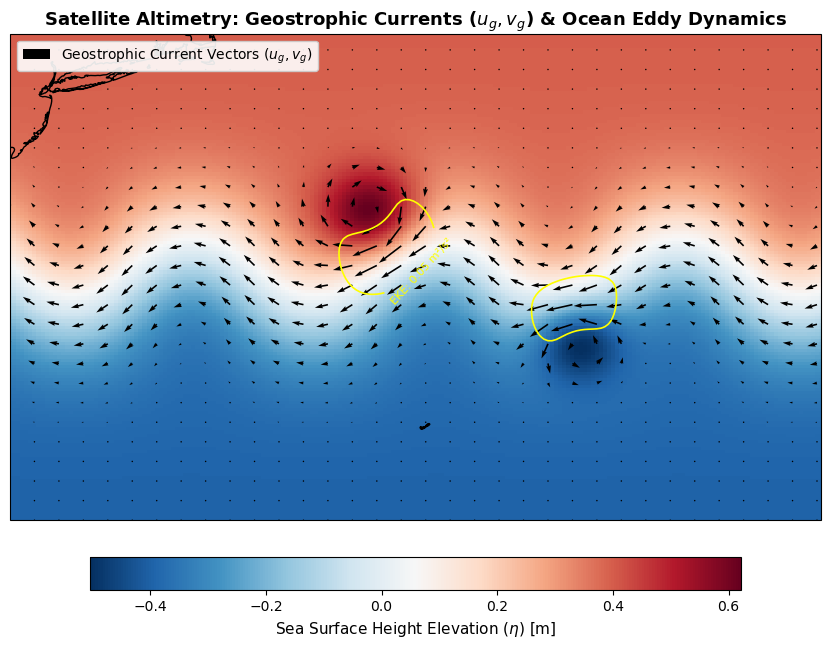

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("Initializing Satellite Altimetry & Geostrophic Eddy Analysis...")

# 1. Define Grid in Gulf Stream Region (30°N to 42°N, 75°W to 55°W)
lats = np.linspace(30.0, 42.0, 150)
lons = np.linspace(-75.0, -55.0, 200)
LON, LAT = np.meshgrid(lons, lats)

# 2. Simulate High-Resolution Sea Surface Height Anomaly (\eta) with Ocean Eddies
# Combining a background ocean front with cyclonic (cold core) and anticyclonic (warm core) eddies
background = 0.4 * np.tanh((LAT - 36.0) / 2.0)
eddy_warm = 0.35 * np.exp(-(((LON - (-66.0))**2 / 1.5) + ((LAT - 37.5)**2 / 1.2)))
eddy_cold = -0.30 * np.exp(-(((LON - (-61.0))**2 / 1.2) + ((LAT - 34.5)**2 / 1.0)))
meander   = 0.15 * np.sin(2 * np.pi * (LON - (-75)) / 6.0) * np.exp(-((LAT - 36)**2)/4.0)

eta = background + eddy_warm + eddy_cold + meander # Sea Surface Height in meters

# 3. Physical Constants & Coriolis Parameter Calculation
g = 9.81              # Acceleration due to gravity (m/s²)
omega = 7.2921e-5     # Earth's angular velocity (rad/s)
f = 2 * omega * np.sin(np.deg2rad(LAT)) # Coriolis parameter (1/s)

# 4. Spatial Grid Spacing (dx, dy in meters)
dy_meters = np.gradient(lats) * 111139.0 # 1° lat ≈ 111,139 m
dx_meters = np.gradient(lons)[np.newaxis, :] * 111139.0 * np.cos(np.deg2rad(LAT))

# 5. Compute Spatial Gradients of SSH (d\eta/dy and d\eta/dx)
deta_dy = np.gradient(eta, axis=0) / dy_meters[:, np.newaxis]
deta_dx = np.gradient(eta, axis=1) / dx_meters

# 6. Apply Geostrophic Balance Equations
# u_g = -(g / f) * (d\eta/dy)
# v_g =  (g / f) * (d\eta/dx)
ug = -(g / f) * deta_dy
vg =  (g / f) * deta_dx

# 7. Calculate Eddy Kinetic Energy (EKE)
eke = 0.5 * (ug**2 + vg**2) # m²/s²

print("Geostrophic velocity vectors and EKE computed successfully!")

# 8. Visualizing Altimetry & Geostrophic Current Vectors
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot Sea Surface Height (\eta) as background contour
mesh = ax.pcolormesh(lons, lats, eta, cmap='RdBu_r', shading='auto', transform=ccrs.PlateCarree())
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.06, shrink=0.7)
cbar.set_label(r'Sea Surface Height Elevation ($\eta$) [m]', fontsize=11)

# Overlay Geostrophic Current Vectors (Subsampled for visual clarity)
skip_y, skip_x = 6, 6
ax.quiver(
    LON[::skip_y, ::skip_x], LAT[::skip_y, ::skip_x], 
    ug[::skip_y, ::skip_x], vg[::skip_y, ::skip_x], 
    color='black', scale=15.0, transform=ccrs.PlateCarree(),
    width=0.002, label=r'Geostrophic Current Vectors ($u_g, v_g$)'
)

# Overlay High EKE Contours (Eddy Cores)
cs = ax.contour(LON, LAT, eke, levels=[0.05, 0.15, 0.30], colors='yellow', linewidths=1.2, transform=ccrs.PlateCarree())
ax.clabel(cs, inline=True, fontsize=8, fmt=r'EKE: %.2f m²/s²')

# Map Details & Features
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([lons[0], lons[-1], lats[0], lats[-1]], crs=ccrs.PlateCarree())

# Titles and Legend
plt.title(r'Satellite Altimetry: Geostrophic Currents ($u_g, v_g$) & Ocean Eddy Dynamics', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

# Save high-resolution figure
plt.savefig("../figures/geostrophic_currents_eddies.png", dpi=300, bbox_inches='tight')
plt.show()